# Importing Libraries, install PyQt for visualisations

In [1]:
import mne
from pathlib import Path
from mne import set_bipolar_reference
from mne.io import read_raw
from mne.preprocessing import ICA
from pipeline.datasets import get_erpcore

# Importing Data

In [2]:
current_dir = Path.cwd()
vhdr_path = current_dir / "Oddball_Experiment" / "Data" / "Oddball.vhdr"
# raw data (preload=True loads samples into RAM for fast filtering/processing)
raw = mne.io.read_raw_brainvision(vhdr_path, preload=True)
raw

Extracting parameters from D:\Study\BTU University Subjects\BCI\MNE Python Tutorial\Oddball_Experiment\Data\Oddball.vhdr...
Setting channel info structure...
Reading 0 ... 687899  =      0.000 ...   687.899 secs...


<RawBrainVision | Oddball.eeg, 54 x 687900 (687.9 s), ~283.5 MiB, data loaded>

# Channel x Time Plot

In [7]:
# Open the interactive time-series browser showing all channels
raw.plot(
    n_channels=len(raw.ch_names),  # Show all channels simultaneously
    duration=10.0,                 # Window length in seconds
    scalings={'eeg':50e-6},               # scale channel amplitudes
    show_options=True,             # Display the settings panel (filters, scales)
    block=True                     # Keep the plot window open in standalone scripts
)

Channels marked as bad:
none


In [4]:
raw.get_data()

array([[ 0.0004634,  0.0004631,  0.0004562, ...,  0.0003623,  0.0003656,
         0.0003607],
       [ 0.0002409,  0.0002384,  0.0002352, ...,  0.0002073,  0.000208 ,
         0.0002009],
       [ 0.0002183,  0.0002164,  0.0002118, ...,  0.0001906,  0.000191 ,
         0.0001838],
       ...,
       [-0.00337  , -0.00337  , -0.00337  , ..., -0.00271  , -0.00271  ,
        -0.00271  ],
       [ 0.00139  ,  0.00138  ,  0.00137  , ...,  0.00273  ,  0.00273  ,
         0.00273  ],
       [-0.0015   , -0.00151  , -0.00151  , ..., -0.00067  , -0.00067  ,
        -0.00068  ]], shape=(54, 687900))

In [5]:
raw.get_data().shape

(54, 687900)

# Checking the channels types and changing the EOG channels type to 'eog'

In [8]:
# When you import an EEG file (like .edf, .bdf, or .vhdr), MNE attempts to infer what each channel contains based on the file header or channel names. In many cases, it defaults to labeling every recorded channel as generic 'eeg'.

# Check how many of each type MNE has assigned:
print(raw.get_channel_types())
# Or check a quick summary:
print(raw)  # Displays e.g. "<Raw | ... 60 EEG, 4 EOG, ...>"


['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg']
<RawBrainVision | Oddball.eeg, 54 x 687900 (687.9 s), ~283.5 MiB, data loaded>


In [9]:
# As you can see, all channels are of type EEG, now set these to 'eog' since these channels measure eye movements
raw.set_channel_types({
    'EOGv1': 'eog',
    'EOGv2': 'eog',
    'EOGh1': 'eog', 
    'EOGh2': 'eog'
})

<RawBrainVision | Oddball.eeg, 54 x 687900 (687.9 s), ~283.5 MiB, data loaded>

# Setting the channel locations on the scalp

In [27]:
print(raw.ch_names)

['Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'PO3', 'POz', 'PO4', 'O1', 'O2', 'EOGv1', 'EOGv2', 'EOGh1', 'EOGh2']


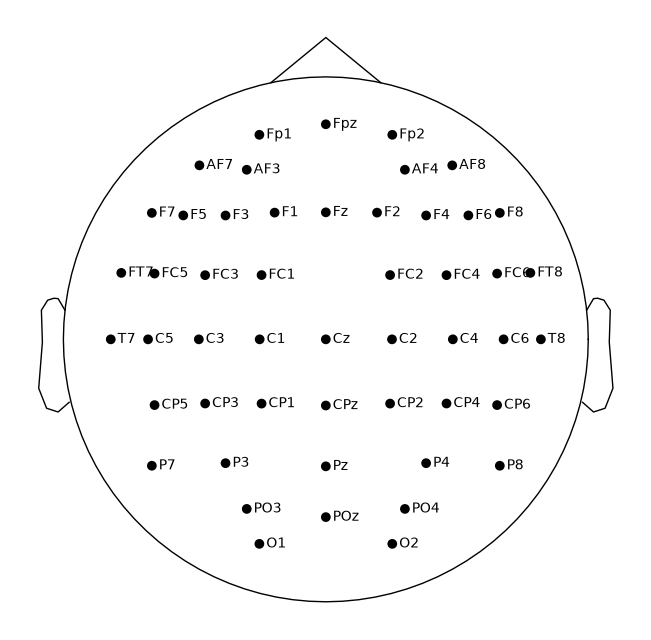

In [24]:
raw = raw.set_montage('biosemi64', match_case=False)
_ = raw.plot_sensors(show_names=True)

In [32]:
raw = raw.filter(l_freq=0.1, h_freq=None)
raw.plot(
    n_channels=len(raw.ch_names),  # Show all channels simultaneously
    duration=10.0,                 # Window length in seconds
    scalings="auto",        # Automatically scale channel amplitudes
    show_options=True,             # Display the settings panel (filters, scales)
    block=True                     # Keep the plot window open in standalone scripts
)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Filter length: 33001 samples (33.001 s)

Channels marked as bad:
none


# ICA Decomposition

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3301 samples (3.301 s)

Fitting ICA to data using 50 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 33.8s.


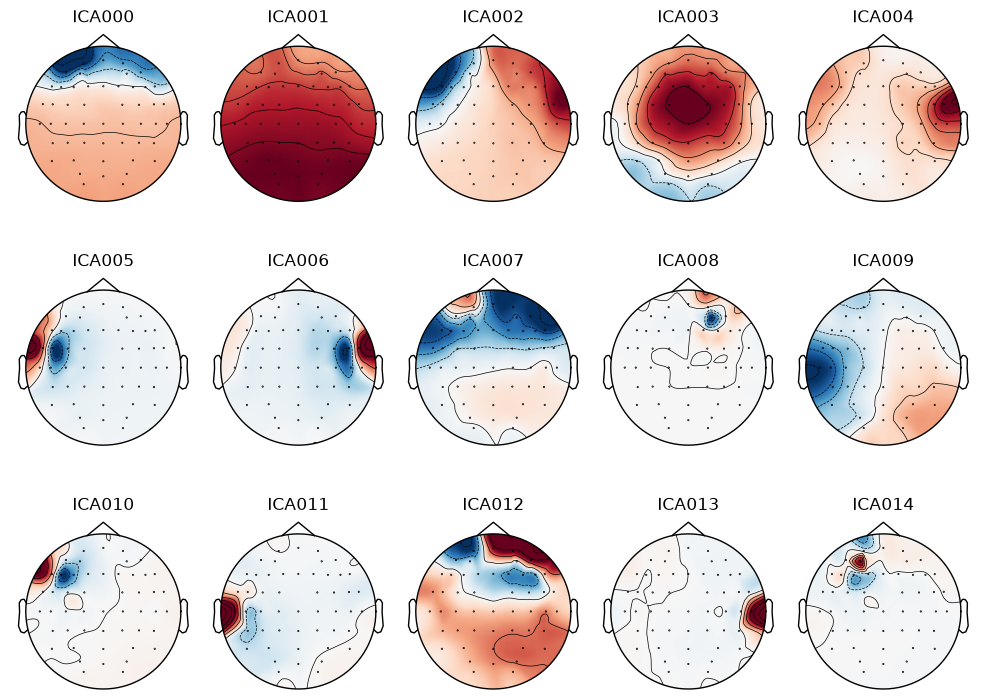

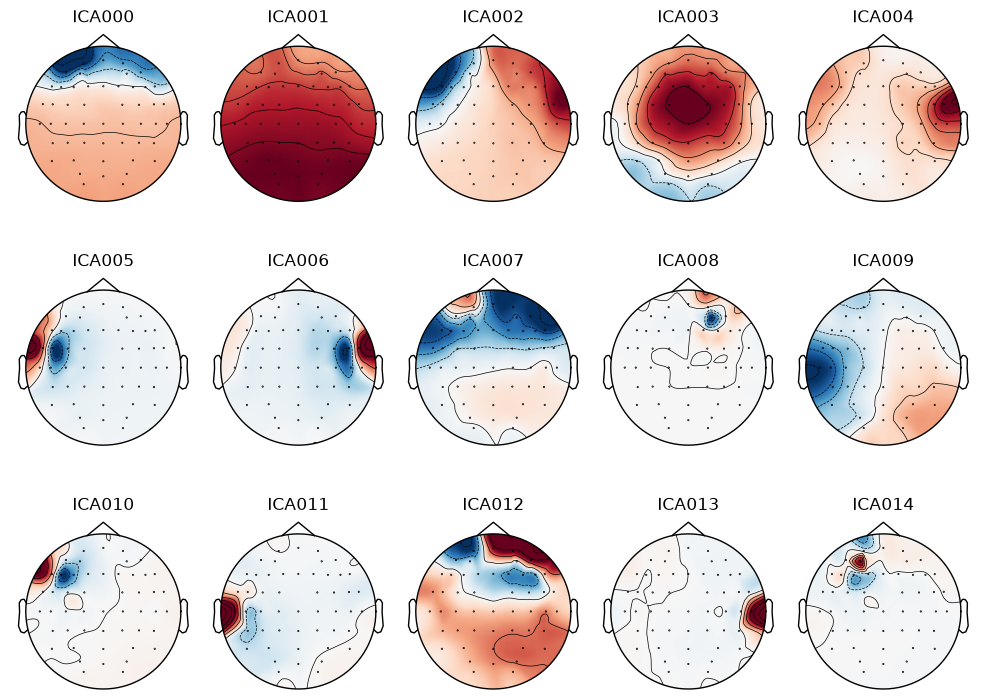

In [38]:
raw_filtered = raw.copy().filter(l_freq=1.0, h_freq=None)
ica = ICA(n_components=15)
ica = ica.fit(raw_filtered)
ica.plot_components()

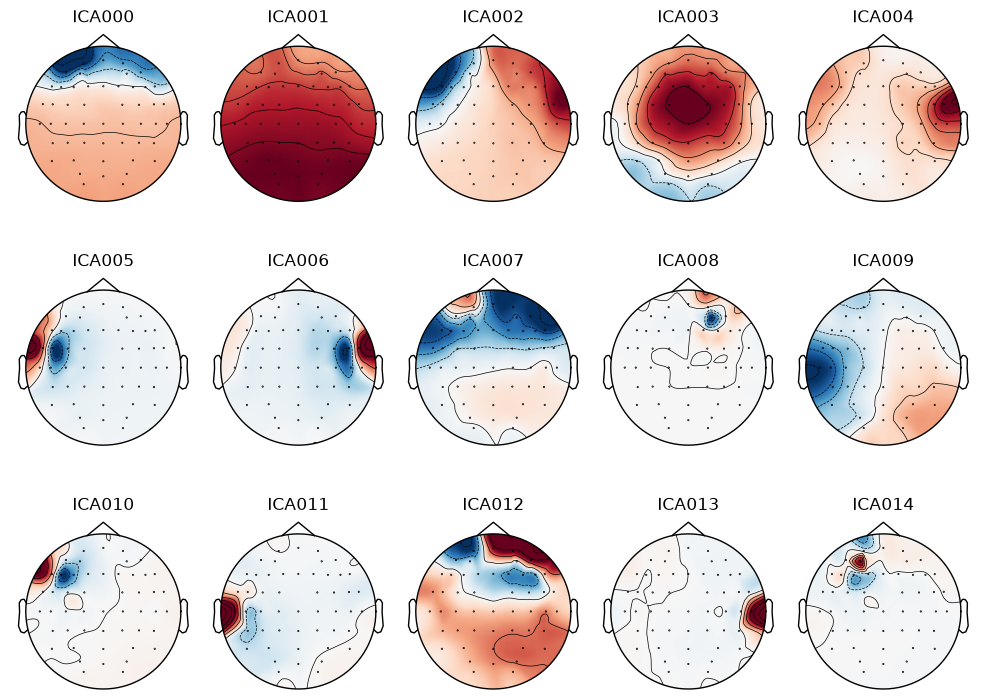

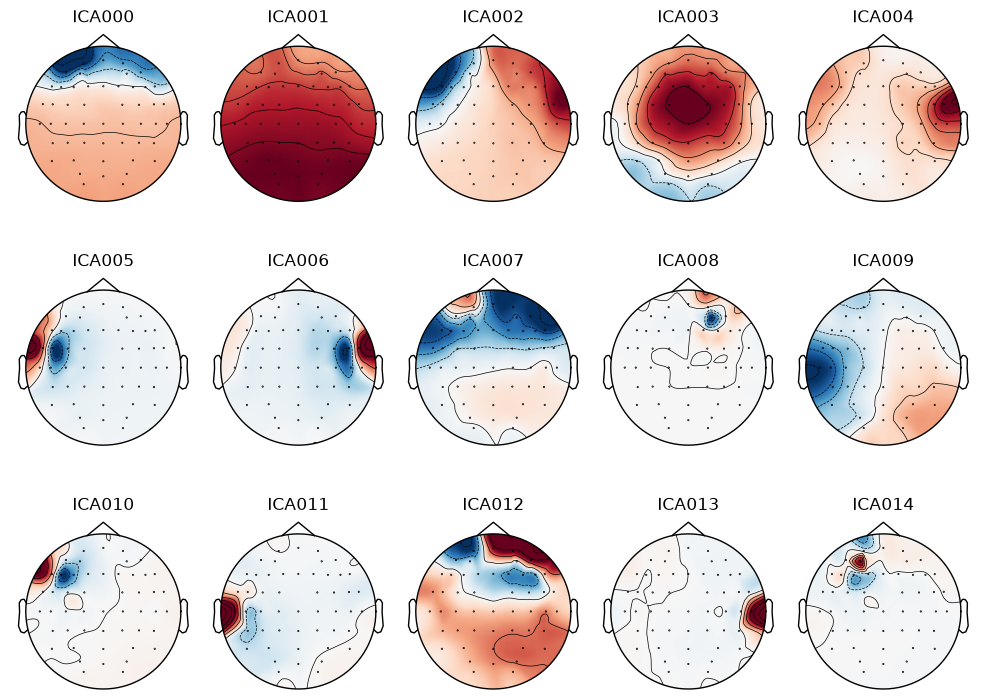

In [39]:
# Clicking any topography turns its label red and adds it to ica.exclude
ica.plot_components()

In [40]:
# Plots component activations over time alongside raw EEG
# Clicking a component's name on the left toggles it as an excluded artifact
ica.plot_sources(raw)

Creating RawArray with float64 data, n_channels=19, n_times=687900
    Range : 0 ... 687899 =      0.000 ...   687.899 secs
Ready.


# Removing EOG channels before epoching

In [34]:
# Create an independent copy before dropping/picking
cleaned = raw.copy()
# Find and drop EOG channels by type
cleaned.drop_channels(cleaned.copy().pick(picks="eog").ch_names)

print(f"Original channels: {len(raw.ch_names)}")
print(f"Cleaned channels:  {len(cleaned.ch_names)}")

Original channels: 54
Cleaned channels:  50
